In [1]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService


from qiskit.circuit import Parameter, ParameterVector

from hubo_qaoa.utils.parameterise_circuit import parameterise_circuit
from hubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit, get_hardware_LR_qaoa_circuit



In [3]:
filename_to_copy_numbers = {
    'test_N4_W6': [2,2,1,1],
    'test_N9_W6': [1,1,0,0,1,0,1,1,1], 
    'test_N10_W6': [1,1,0,0,1,0,1,1,0,1],
}

In [4]:
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

In [5]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)



In [6]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingheavy-hex.precompute.60.pkl'
with open(data_file, 'rb') as f:
    res_hardware = pickle.load(f)

In [8]:
files_to_plot = list(res_hardware.keys())
files_to_plot

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N4_W6',
 'test_N7_W4',
 'test_N7_W5',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W4',
 'test_N8_W5',
 'test_N8_W6',
 'test_N9_W6',
 'test_N10_W6']

In [9]:
delta_b, delta_g = 0.75, 0.30
p = 1

In [11]:
depths_abstract = []
counts_abstract = []
widths = []
for filename in files_to_plot:
    try:
        cost_circuit = res[filename]['rzz']['circuit']
        num_qubits = cost_circuit.num_qubits
        phis = ParameterVector('ϕ', num_qubits)
        fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)
        
        widths.append(num_qubits)
        depths_abstract.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_abstract.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except:
        pass
widths = np.array(widths)    
depths_abstract = np.array(depths_abstract)    
counts_abstract = np.array(counts_abstract)    


15:06:17 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 15
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 145
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 173
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 227
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 398
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 771
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 268
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 850
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1127
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 300
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 554
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 613
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 896
15:06:18 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1040


In [14]:
widths_hardware = []
depths_hardware = []
counts_hardware = []
for filename in files_to_plot:
    cost_circuit = res_hardware[filename]['rzz']['circuit']
    try:
        num_qubits = res[filename]['rzz']['circuit'].num_qubits
    except:
        from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
        filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
        _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
        print(filename, n, T)
        num_qubits: int = n*T
        
    phis = ParameterVector('ϕ', num_qubits)
    layout = res_hardware[filename]['rzz']['layout']
    try:
        fixed_qc, _, _ = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)    
        widths_hardware.append(num_qubits)
        depths_hardware.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_hardware.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except Exception as e:
        print(e)
widths_hardware = np.array(widths_hardware)    
depths_hardware = np.array(depths_hardware)    
counts_hardware = np.array(counts_hardware)     

15:08:41 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 94
15:08:41 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1023
15:08:42 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1041
15:08:43 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1899
15:08:44 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 4213
15:08:49 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 8007
15:08:50 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 2886
15:09:06 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 12757
15:10:00 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 14831
15:10:02 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 4241
15:10:06 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 6900
15:10:14 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 8164
15:10:31 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 11005
15:11:05 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 13557
test

: 

In [ ]:
indices = np.argsort(widths)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(res.keys()))[index], widths[index], depths_abstract[index], counts_abstract[index])

filename qubits depths count
test_N2_W2 4 10 10
test_N8_W2 8 279 369
test_N8_W3 12 535 758
test_N4_W5 15 214 345
test_N8_W4 16 582 943
test_N4_W6 18 255 422
test_N8_W5 20 856 1434
test_N8_W6 24 895 2381


In [ ]:
indices = np.argsort(widths_hardware)
print('filename qubits depths count')
for index in indices:
    print(files_to_plot[index], widths_hardware[index], depths_hardware[index], counts_hardware[index])

filename qubits depths count
test_N2_W2 4 21 26
test_N8_W2 8 1406 1794
test_N8_W3 12 2370 3913
test_N4_W5 15 649 1388
test_N8_W4 16 2752 4985
test_N4_W6 18 991 1964
test_N8_W5 20 3402 7741
test_N8_W6 24 4519 10680


In [ ]:
"""
(no precompute)
filename qubits depths count
test_N2_W2 4 23 28
test_N7_W2 8 1398 2015
test_N8_W2 8 1251 1864
trivial 9 305 533
test_N7_W3 12 2794 4697
test_N3_W4 12 299 700
test_N8_W3 12 2444 4057
test_N4_W5 15 931 1691
test_N8_W4 16 2854 5265
test_N7_W4 16 4570 8663
test_N4_W6 18 848 1695
test_N7_W5 20 5575 12571
test_N8_W5 20 3282 7758
"""

'\n(no precompute)\nfilename qubits depths count\ntest_N2_W2 4 23 28\ntest_N7_W2 8 1398 2015\ntest_N8_W2 8 1251 1864\ntrivial 9 305 533\ntest_N7_W3 12 2794 4697\ntest_N3_W4 12 299 700\ntest_N8_W3 12 2444 4057\ntest_N4_W5 15 931 1691\ntest_N8_W4 16 2854 5265\ntest_N7_W4 16 4570 8663\ntest_N4_W6 18 848 1695\ntest_N7_W5 20 5575 12571\ntest_N8_W5 20 3282 7758\n'

In [ ]:
files_to_fit = [
    "test_N8_W2" ,
    "test_N8_W3" ,
    "test_N8_W4" ,
    "test_N8_W5" ,
    "test_N8_W6" ,
]
indices_to_fit = [files_to_plot.index(f) for f in files_to_fit]

In [ ]:
grid = np.linspace(
    min(widths[indices_to_fit][0], widths_hardware[indices_to_fit][0]),
    max(widths[indices_to_fit][-1], widths_hardware[indices_to_fit][-1]), 
    100
)

p_depth = np.polynomial.Polynomial.fit(widths[indices_to_fit], depths_abstract[indices_to_fit], 1, full=True)
p_depth_hardware = np.polynomial.Polynomial.fit(widths_hardware[indices_to_fit], depths_hardware[indices_to_fit], 1, full=True)
p_count = np.polynomial.Polynomial.fit(widths[indices_to_fit], counts_abstract[indices_to_fit], 1)
p_count_hardware = np.polynomial.Polynomial.fit(widths_hardware[indices_to_fit], counts_hardware[indices_to_fit], 1)
print(p_depth)
print(p_depth_hardware)
p_depth = p_depth[0]
p_depth_hardware = p_depth_hardware[0]

(Polynomial([629.4, 310.6], domain=[ 8., 24.], window=[-1.,  1.], symbol='x'), [array([14648.3]), np.int32(2), array([1., 1.]), np.float64(1.1102230246251565e-15)])
(Polynomial([2889.8, 1451.6], domain=[ 8., 24.], window=[-1.,  1.], symbol='x'), [array([139628.4]), np.int32(2), array([1., 1.]), np.float64(1.1102230246251565e-15)])


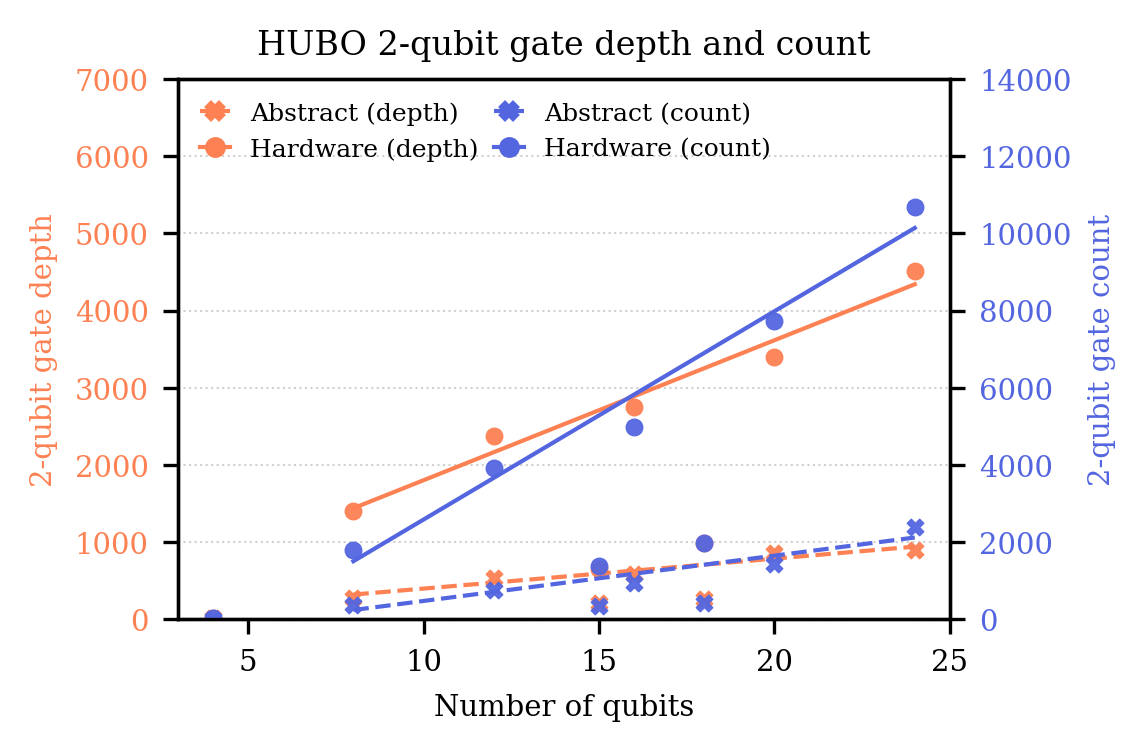

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator

# --- helper for rounding y-axis nicely (keep your existing function if preferred) ---
def nice_upper_limit(data, n_ticks=6):
    max_val = np.max(data)
    raw_step = max_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(raw_step))
    residual = raw_step / magnitude
    if residual < 1:
        nice_step = 1 * magnitude
    elif residual < 2:
        nice_step = 2 * magnitude
    elif residual < 2.5:
        nice_step = 2.5 * magnitude
    elif residual < 5:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    upper = nice_step * (n_ticks - 1)
    return upper, nice_step

# ---- compact publication style for small panels ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "lines.linewidth": 1.2,
})

# small figure sized so two can sit side-by-side on A4 with 1 in margins
fig, ax1 = plt.subplots(figsize=(3.1, 2.4))

# colours & markers
depth_color = "#FD8153"
count_color = '#5366E0'
abstract_marker = 'X'
hardware_marker = 'o'

# reduced marker and line sizes for compactness
marker_size = 4        # smaller marker
edge_width = 0.3
linewidth_fit = 1.0
alpha_scatter = 0.95

# --- Depth (left axis) ---
ax1.scatter(widths, depths_abstract,
            color=depth_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.scatter(widths_hardware, depths_hardware,
            color=depth_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.plot(grid, p_depth(grid), linestyle='--', color=depth_color,
         linewidth=linewidth_fit)
ax1.plot(grid, p_depth_hardware(grid), linestyle='-', color=depth_color,
         linewidth=linewidth_fit)

ax1.set_xlabel('Number of qubits', fontsize=7)
ax1.set_ylabel('2-qubit gate depth', color=depth_color, fontsize=7)
ax1.tick_params(axis='y', labelcolor=depth_color, labelsize=7)
ax1.xaxis.set_major_locator(MaxNLocator(5))  # fewer, neat x-ticks
ax1.tick_params(axis='x', labelsize=7)

# --- Count (right axis) ---
ax2 = ax1.twinx()
ax2.scatter(widths, counts_abstract,
            color=count_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.scatter(widths_hardware, counts_hardware,
            color=count_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.plot(grid, p_count(grid), linestyle='--', color=count_color,
         linewidth=linewidth_fit)
ax2.plot(grid, p_count_hardware(grid), linestyle='-', color=count_color,
         linewidth=linewidth_fit)

ax2.set_ylabel('2-qubit gate count', color=count_color, fontsize=7)
ax2.tick_params(axis='y', labelcolor=count_color, labelsize=7)

# ---- nice rounded axes (same number of horizontal gridlines) ----
n_ticks = 8
depth_data = np.concatenate([depths_abstract, depths_hardware])
depth_upper, depth_step = nice_upper_limit(depth_data, n_ticks)
ax1.set_ylim(0, depth_upper)
ax1.yaxis.set_major_locator(MultipleLocator(depth_step))

count_data = np.concatenate([counts_abstract, counts_hardware])
count_upper, count_step = nice_upper_limit(count_data, n_ticks)
ax2.set_ylim(0, count_upper)
ax2.yaxis.set_major_locator(MultipleLocator(count_step))

# only draw gridlines from left axis for aligned horizontal guides
ax1.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
ax2.grid(False)

# ---- compact combined legend (use 2 columns to conserve vertical space) ----
legend_elements = [
    Line2D([0], [0], color=depth_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (depth)'),
    Line2D([0], [0], color=depth_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (depth)'),
    Line2D([0], [0], color=count_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (count)'),
    Line2D([0], [0], color=count_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (count)'),
]
# place legend inside top-left without a frame, 2 columns
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 1.0),
           frameon=False, ncol=2, handlelength=1.2, columnspacing=0.6,
           fontsize=6)

# Title and layout adjustments for the small panel
ax1.set_title('HUBO 2-qubit gate depth and count', fontsize=8, pad=6)
fig.subplots_adjust(left=0.11, right=0.94, top=0.88, bottom=0.13)

# Save at publication resolution (vector PDF + PNG)
fig.savefig('../../../out/hubo_2qubit_depth_count_small.png', bbox_inches='tight', dpi=300)

plt.show()

In [10]:
filename = 'test_N4_W5'
cost_circuit = res_hardware[filename]['rzz']['circuit']

try:
    num_qubits = res[filename]['rzz']['circuit'].num_qubits
except:
    from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
    print(filename, n, T)
    num_qubits: int = n*T
    
phis = ParameterVector('ϕ', num_qubits)
layout = res_hardware[filename]['rzz']['layout']

fixed_qc, circuit, layout_circuit = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)
    

Compiling to backend with opt 3
09:29:51 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 2186


In [16]:
layout_circuit.count_ops(),fixed_qc.count_ops()

(OrderedDict([('swap', 442),
              ('cx', 414),
              ('rzz', 121),
              ('rz', 95),
              ('ry', 45),
              ('measure', 15)]),
 OrderedDict([('sx', 2520),
              ('rz', 1647),
              ('cz', 1344),
              ('delay', 987),
              ('measure', 15),
              ('x', 5)]))

In [14]:
cost_circuit = res[filename]['rzz']['circuit']
num_qubits = cost_circuit.num_qubits
phis = ParameterVector('ϕ', num_qubits)
abstract_fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)

09:31:21 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 227


In [15]:
abstract_fixed_qc.count_ops()

OrderedDict([('rzz', 177),
             ('cx', 168),
             ('ry', 45),
             ('rz', 39),
             ('measure', 15),
             ('barrier', 1)])

In [13]:
(442/(442+414+121))

0.4524053224155578

In [ ]:
cost_circuit.count_ops()

OrderedDict([('swap', 553), ('cx', 396), ('rzz', 171), ('rz', 30)])

In [ ]:
res_hardware[filename]['default']['circuit'].count_ops()

OrderedDict([('cx', 1034), ('rz', 156), ('rzz', 45)])

In [ ]:
layout_circuit.count_ops(), fixed_qc.count_ops(),qaoa_circuit.count_ops()

(OrderedDict([('swap', 553),
              ('cx', 396),
              ('rzz', 171),
              ('ry', 45),
              ('rz', 45),
              ('measure', 15)]),
 OrderedDict([('sx', 3193),
              ('rz', 1727),
              ('cz', 1703),
              ('measure', 15),
              ('x', 4)]),
 OrderedDict([('swap', 553),
              ('cx', 396),
              ('rzz', 171),
              ('ry', 45),
              ('rz', 45),
              ('measure', 15)]))

In [ ]:
circuit.count_ops()

OrderedDict([('sx', 3193),
             ('rz', 1727),
             ('cz', 1703),
             ('measure', 15),
             ('x', 4)])

In [ ]:
from qiskit import generate_preset_pass_manager
generic_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method="alap")
t_qaoa_circuit = generic_pm.run(qaoa_circuit)

In [ ]:
t_qaoa_circuit.count_ops()

OrderedDict([('sx', 2873),
             ('rz', 1665),
             ('cz', 1551),
             ('delay', 1064),
             ('measure', 15),
             ('x', 5)])

In [ ]:
t_qaoa_circuit.draw(fold=-1, idle_wires=False)

global phase: 19095.385546682737 - 39.49999999999999*γ[0]
           ┌─────────────────┐      ┌────┐      ┌──────────────┐ ┌────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     ┌────┐                  ┌────┐                 ┌─────────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    